In [3]:
import torch
import torch.nn.functional as F
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
print("Matplotlib version:", matplotlib.__version__)
print("Backend:", matplotlib.get_backend())
print("Matplotlib import OK")
print("Pyplot import OK")

Matplotlib version: 3.9.4
Backend: module://matplotlib_inline.backend_inline
Matplotlib import OK
Pyplot import OK


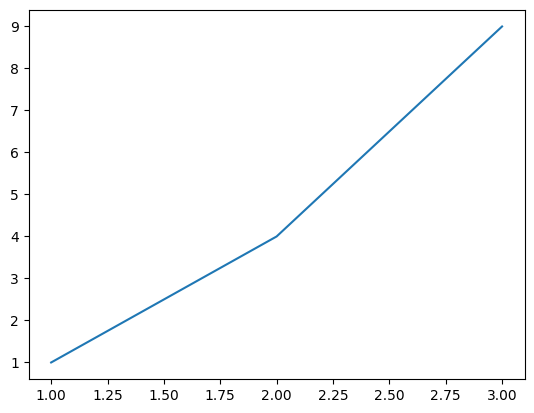

In [4]:
plt.plot([1, 2, 3], [1, 4, 9])
plt.show()

In [5]:
import urllib.request

url = "https://raw.githubusercontent.com/karpathy/makemore/master/names.txt"

urllib.request.urlretrieve(url, "names.txt")

('names.txt', <http.client.HTTPMessage at 0x1c49dae8d60>)

In [6]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [7]:
len(words)

32033

In [8]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i , s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [9]:
# Building our training dataset
block_size = 3            # context length : how many characters do we take to predict the next character?
X , Y  = [], []

for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        index = stoi[ch]
        X.append(context)
        Y.append(index)
        print(''.join(itos[i] for i in context), '----->' , itos[index])
        context = context[1:] + [index]           # crop and append
X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... -----> e
..e -----> m
.em -----> m
emm -----> a
mma -----> .
olivia
... -----> o
..o -----> l
.ol -----> i
oli -----> v
liv -----> i
ivi -----> a
via -----> .
ava
... -----> a
..a -----> v
.av -----> a
ava -----> .
isabella
... -----> i
..i -----> s
.is -----> a
isa -----> b
sab -----> e
abe -----> l
bel -----> l
ell -----> a
lla -----> .
sophia
... -----> s
..s -----> o
.so -----> p
sop -----> h
oph -----> i
phi -----> a
hia -----> .


In [10]:
X.shape , Y.shape , X.dtype , Y.dtype

(torch.Size([32, 3]), torch.Size([32]), torch.int64, torch.int64)

In [11]:
X , Y

(tensor([[ 0,  0,  0],
         [ 0,  0,  5],
         [ 0,  5, 13],
         [ 5, 13, 13],
         [13, 13,  1],
         [ 0,  0,  0],
         [ 0,  0, 15],
         [ 0, 15, 12],
         [15, 12,  9],
         [12,  9, 22],
         [ 9, 22,  9],
         [22,  9,  1],
         [ 0,  0,  0],
         [ 0,  0,  1],
         [ 0,  1, 22],
         [ 1, 22,  1],
         [ 0,  0,  0],
         [ 0,  0,  9],
         [ 0,  9, 19],
         [ 9, 19,  1],
         [19,  1,  2],
         [ 1,  2,  5],
         [ 2,  5, 12],
         [ 5, 12, 12],
         [12, 12,  1],
         [ 0,  0,  0],
         [ 0,  0, 19],
         [ 0, 19, 15],
         [19, 15, 16],
         [15, 16,  8],
         [16,  8,  9],
         [ 8,  9,  1]]),
 tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
          1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0]))

In [12]:
X[13,2]

tensor(1)

In [13]:
# Implementing the embedding  lookup table
C = torch.randn((27, 2))

In [14]:
C

tensor([[-0.2650,  0.8585],
        [-1.3885, -1.2285],
        [ 0.0497,  0.1025],
        [ 1.3681, -0.3912],
        [-1.1348,  0.8351],
        [-1.1025, -0.8774],
        [-0.2042, -0.2072],
        [-0.6430,  0.6705],
        [ 1.3148,  1.5277],
        [ 1.9286, -0.3484],
        [ 0.3423,  1.2818],
        [ 0.3809,  1.1971],
        [ 0.0374, -0.2857],
        [ 0.1206, -0.2267],
        [ 1.4144,  0.4157],
        [-0.4836, -2.2041],
        [ 1.2109,  0.7838],
        [-0.2353,  0.0956],
        [-0.4191, -0.2552],
        [-0.9203,  0.3113],
        [-0.9208,  0.8640],
        [ 0.2231,  0.0799],
        [-0.7474,  0.0501],
        [-0.4484, -0.0296],
        [-0.5085,  0.8207],
        [ 0.3492, -1.7931],
        [ 0.2318,  0.7526]])

In [15]:
C[5]

tensor([-1.1025, -0.8774])

In [16]:
emb = C[X]   
# what is C actually doing..?
# character ID     embedding
#      0        →  [0.21, -0.43]
#      1        →  [1.12,  0.54]
#      2        →  [-0.32, 0.91]
#      3        →  [0.45, -1.21]
#      ...

In [17]:
emb.shape

torch.Size([32, 3, 2])

In [18]:
C[X][13,2]

tensor([-1.3885, -1.2285])

In [19]:
C[1]

tensor([-1.3885, -1.2285])

In [20]:
# implementing the hidden layer for tanh
W1 = torch.randn((6 , 100))
b1 = torch.randn(100)

In [21]:
h = torch.tanh(emb @ W1 + b1)   # as emb is (32 , 3, 2) and W1 is (6 ,100) so multiplication can not work

RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x2 and 6x100)

In [ ]:
# for multiplication of emb and W1 we have to change the shape of emb to (32 ,6)
torch.cat(torch.unbind(emb , 1) , 1).shape    # this will unbind emb on 1st index and then concate all of 3 tensors

In [ ]:
# for multiplication of emb and W1 we have to change the shape of emb to (32 ,6) 
emb.view(32, 6).shape     # this one is more efficient than concate and bind

In [ ]:
# so now we can make h as
h = torch.tanh(emb.view(emb.shape[0] , 6) @ W1 + b1)

In [ ]:
h

In [22]:
h.shape

NameError: name 'h' is not defined

In [23]:
# implementing the output layer
W2 = torch.randn((100 , 27))
b2 = torch.randn(27)

In [24]:
logits = h @ W2 + b2
logits.shape

NameError: name 'h' is not defined

In [25]:
logits

NameError: name 'logits' is not defined

In [26]:
counts = logits.exp()

NameError: name 'logits' is not defined

In [27]:
probs = counts / counts.sum(1 , keepdim = True)

NameError: name 'counts' is not defined

In [28]:
loss = -probs[torch.arange(32) , Y].log().mean()
loss

NameError: name 'probs' is not defined

In [29]:
# putting everything together
block_size = 3            
X , Y  = [], []

for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        index = stoi[ch]
        X.append(context)
        Y.append(index)
        print(''.join(itos[i] for i in context), '----->' , itos[index])
        context = context[1:] + [index]           
X = torch.tensor(X)
Y = torch.tensor(Y)

print('-----')
print(X.shape , Y.shape)
print('-----')

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2) , generator = g)
W1 = torch.randn((6 , 100) , generator = g)
b1 = torch.randn(100 , generator = g)
W2 = torch.randn((100 , 27), generator = g)
b2 = torch.randn(27 , generator = g)

parameters = [W1 , W2 , b1, b2 , C]
print(sum(p.nelement() for p in parameters))
print('-----')

emb = C[X]   
h = torch.tanh(emb.view(emb.shape[0] , 6) @ W1 + b1)
logits = h @ W2 + b2
counts = logits.exp()
probs = counts / counts.sum(1 , keepdim = True)
loss = -probs[torch.arange(32) , Y].log().mean()
loss

emma
... -----> e
..e -----> m
.em -----> m
emm -----> a
mma -----> .
olivia
... -----> o
..o -----> l
.ol -----> i
oli -----> v
liv -----> i
ivi -----> a
via -----> .
ava
... -----> a
..a -----> v
.av -----> a
ava -----> .
isabella
... -----> i
..i -----> s
.is -----> a
isa -----> b
sab -----> e
abe -----> l
bel -----> l
ell -----> a
lla -----> .
sophia
... -----> s
..s -----> o
.so -----> p
sop -----> h
oph -----> i
phi -----> a
hia -----> .
-----
torch.Size([32, 3]) torch.Size([32])
-----
3481
-----


tensor(17.7697)

In [30]:
# counts = logits.exp()
# probs = counts / counts.sum(1 , keepdim = True)
# loss = -probs[torch.arange(32) , Y].log().mean()
# instead of using these 3 lines we can use cross_entropy to find out loss
loss = F.cross_entropy(logits , Y)
loss

tensor(17.7697)

In [31]:
# there is many good reasons to call cross_entropy
# 1. forward pass can be much more efficient
# 2. backward pass can be much more efficient
# 3. things can be much more numerically well-behaved

In [32]:
for p in parameters:
    p.requires_grad = True

In [33]:
# Decreasing loss by iterating over forward pass , backward pass and update
for _ in range(100):
    
    # forward pass
    emb = C[X]   
    h = torch.tanh(emb.view(emb.shape[0] , 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits , Y)
    
    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += -0.1 * p.grad

loss.item()

0.3367389440536499

In [34]:
# putting everything together for entire dataset
block_size = 3            
X , Y  = [], []

for w in words:
#     print(w)
    context = [0] * block_size
    for ch in w + '.':
        index = stoi[ch]
        X.append(context)
        Y.append(index)
#         print(''.join(itos[i] for i in context), '----->' , itos[index])
        context = context[1:] + [index]           
X = torch.tensor(X)
Y = torch.tensor(Y)

print('-----')
print(X.shape , Y.shape)
print('-----')

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2) , generator = g)
W1 = torch.randn((6 , 100) , generator = g)
b1 = torch.randn(100 , generator = g)
W2 = torch.randn((100 , 27), generator = g)
b2 = torch.randn(27 , generator = g)

parameters = [W1 , W2 , b1, b2 , C]
print(sum(p.nelement() for p in parameters))
print('-----')

for p in parameters:
    p.requires_grad = True
    
for _ in range(10):
    
    # forward pass
    emb = C[X]   
    h = torch.tanh(emb.view(emb.shape[0] , 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits , Y)
    print(loss.item())
    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += -0.1 * p.grad

-----
torch.Size([228146, 3]) torch.Size([228146])
-----
3481
-----
19.505229949951172
17.084491729736328
15.776531219482422
14.833340644836426
14.002603530883789
13.25325870513916
12.579917907714844
11.983101844787598
11.47049331665039
11.05185604095459


In [35]:
# minibatch for this neural network which are more efficient
for _ in range(10):
    
    # Randomly select 32 row indices from the dataset, where each index is between 0 and 228145.
    ix = torch.randint(0, X.shape[0] , (32,))   # torch.randint(low , high , size)
    
    # forward pass
    emb = C[X[ix]]   
    h = torch.tanh(emb.view(emb.shape[0] , 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits , Y[ix])
    print(loss.item())
    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += -0.1 * p.grad

10.866411209106445
10.52879810333252
10.941352844238281
10.914464950561523
9.7769775390625
7.199187755584717
7.450461387634277
8.402938842773438
11.204445838928223
9.199163436889648


In [36]:
# finding out good learning rate 
# means whenever we update out p.data as 0.1 then 0.1 is good learning rate or there is something that actually minimize the loss

# torch.linspace(0.001 , 1 , 1000)    for this exponent like 0.001 = 10**-3 & 1 = 10**0
lre = torch.linspace(-3 , 0 , 1000)       # lre = learning rate exponents
lrs = 10**lre        #lrs = learning rates

In [37]:
lri = []
lossi = []

for i in range(1000):
    
    ix = torch.randint(0, X.shape[0] , (32,))   # torch.randint(low , high , size)
    
    # forward pass
    emb = C[X[ix]]   
    h = torch.tanh(emb.view(emb.shape[0] , 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits , Y[ix])
#     print(loss.item())
    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad
    
    # tracking states
    lri.append(lre[i])
    lossi.append(loss.item())
    
print(loss.item())

6.616158962249756


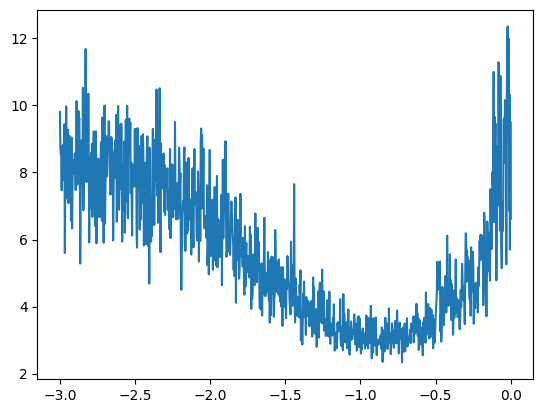

In [38]:
plt.plot(lri , lossi)         
# from the graph good learning rate is 0.1

In [39]:
# learning rate decay means we are going to take our learning rate (0.1) and we are going to 10x lower it(0.01)
lri = []
lossi = []

for i in range(1000):
    
    ix = torch.randint(0, X.shape[0] , (32,))   # torch.randint(low , high , size)
    
    # forward pass
    emb = C[X[ix]]   
    h = torch.tanh(emb.view(emb.shape[0] , 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits , Y[ix])
#     print(loss.item())
    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # tracking states
    lri.append(lre[i])
    lossi.append(loss.item())
    
print(loss.item())

3.1858222484588623


In [40]:
def build_dataset(wwords):
    block_size = 3            
    X , Y  = [], []

    for w in words:
    #     print(w)
        context = [0] * block_size
        for ch in w + '.':
            index = stoi[ch]
            X.append(context)
            Y.append(index)
    #         print(''.join(itos[i] for i in context), '----->' , itos[index])
            context = context[1:] + [index]           
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape , Y.shape)
    return X , Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr , Ytr = build_dataset(words[:n1])          # n1 = 25626 examples are used to training 
Xdev , Ydev = build_dataset(words[n1:n2])      # n2 - n1 = 3203 examples are used to development
Xte , Yte = build_dataset(words[n2:])          # len(words) - n2 = 3204 examples are used to testing

torch.Size([228146, 3]) torch.Size([228146])
torch.Size([228146, 3]) torch.Size([228146])
torch.Size([228146, 3]) torch.Size([228146])


In [41]:
n1 , n2 , n2-n1 , len(words) - n2

(25626, 28829, 3203, 3204)

In [42]:
# forward pass
emb = C[Xtr]  
h = torch.tanh(emb.view(emb.shape[0] , 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits , Ytr)  
print(loss.item())

3.1321260929107666


In [43]:
# forward pass
emb = C[Xdev]   
h = torch.tanh(emb.view(emb.shape[0] , 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits , Ydev)    
print(loss.item())

3.1321260929107666


In [44]:
# forward pass
emb = C[Xte[ix]]   
h = torch.tanh(emb.view(emb.shape[0] , 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits , Yte[ix])    
print(loss.item())

3.031176805496216


In [52]:
# HERE we can see that training loss and dev loss are equal 
# so we have to make performance improvement by scaling up the size of neural network 
def build_dataset(words):
    block_size = 3            
    X , Y  = [], []

    for w in words:
    #     print(w)
        context = [0] * block_size
        for ch in w + '.':
            index = stoi[ch]
            X.append(context)
            Y.append(index)
    #         print(''.join(itos[i] for i in context), '----->' , itos[index])
            context = context[1:] + [index]           
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape , Y.shape)
    return X , Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))

n2 = int(0.9*len(words))

Xtr , Ytr = build_dataset(words[:n1])          # n1 = 25626 examples are used to training 
Xdev , Ydev = build_dataset(words[n1:n2])      # n2 - n1 = 3203 examples are used to development
Xte , Yte = build_dataset(words[n2:])          # len(words) - n2 = 3204 examples are used to testing

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2) , generator = g)
W1 = torch.randn((6 , 300) , generator = g)      # increasing hidden layer from 100 to 300
b1 = torch.randn(300 , generator = g)
W2 = torch.randn((300 , 27), generator = g)
b2 = torch.randn(27 , generator = g)

parameters = [W1 , W2 , b1, b2 , C]
print(sum(p.nelement() for p in parameters))
print('-----')

for p in parameters:
    p.requires_grad = True
    
lre = torch.linspace(-3 , 0 , 1000)      
lrs = 10**lre        
lri = []
lossi = []

for i in range(1000):
    
    ix = torch.randint(0, X.shape[0] , (32,))   # torch.randint(low , high , size)
    
    # forward pass
    emb = C[X[ix]]   
    h = torch.tanh(emb.view(emb.shape[0] , 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits , Y[ix])
#     print(loss.item())
    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # tracking states
    lri.append(lre[i])
    lossi.append(loss.item())
    
print(loss.item())

torch.Size([182441, 3]) torch.Size([182441])
torch.Size([22902, 3]) torch.Size([22902])
torch.Size([22803, 3]) torch.Size([22803])
10281
-----
3.8571574687957764


In [53]:
# forward pass
emb = C[Xtr]  
h = torch.tanh(emb.view(emb.shape[0] , 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits , Ytr)  
print(loss.item())

3.6913323402404785


In [54]:
# forward pass
emb = C[Xdev]   
h = torch.tanh(emb.view(emb.shape[0] , 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits , Ydev)    
print(loss.item())

3.6928775310516357


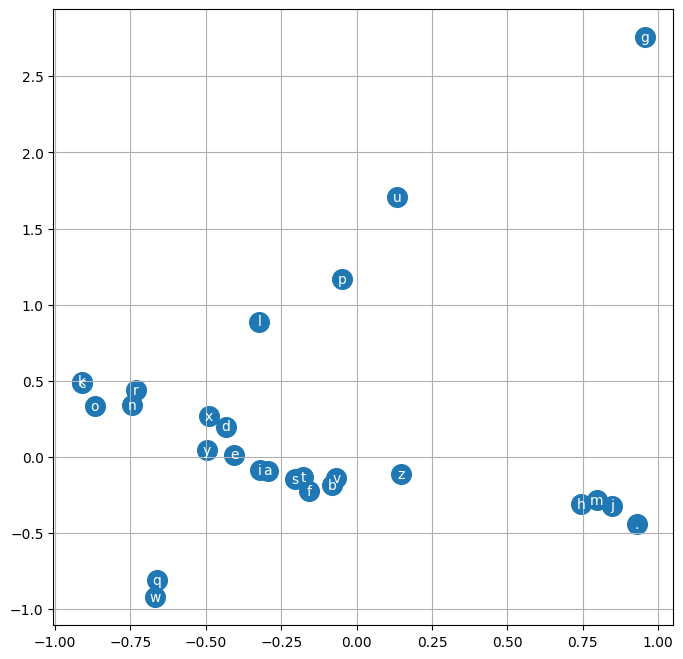

In [48]:
# Here we can see that training loss and dev loss are approximately equal.
# This suggests that the model is not significantly overfitting.
# Since our embedding size is very small (2), we can try increasing it
# to give the model more capacity and see if the loss improves.
# First, we visualize the character embeddings.
plt.figure(figsize = (8,8))
plt.scatter(C[:,0].data , C[:,1].data , s =200 )
for i in range(C.shape[0]):
    plt.text(C[i,0].item() , C[i,1].item() , itos[i] , ha='center' , va='center' , color="white")
plt.grid('minor')

In [75]:
 def build_dataset(words):
    block_size = 3            
    X , Y  = [], []

    for w in words:
    #     print(w)
        context = [0] * block_size
        for ch in w + '.':
            index = stoi[ch]
            X.append(context)
            Y.append(index)
    #         print(''.join(itos[i] for i in context), '----->' , itos[index])
            context = context[1:] + [index]           
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape , Y.shape)
    return X , Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr , Ytr = build_dataset(words[:n1])          # n1 = 25626 examples are used to training 
Xdev , Ydev = build_dataset(words[n1:n2])      # n2 - n1 = 3203 examples are used to development
Xte , Yte = build_dataset(words[n2:])          # len(words) - n2 = 3204 examples are used to testing

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10) , generator = g)         # increasing the size of embedding from 2 to 10
W1 = torch.randn((30 , 200) , generator = g)      
b1 = torch.randn(200 , generator = g)
W2 = torch.randn((200 , 27), generator = g)
b2 = torch.randn(27 , generator = g)

parameters = [W1 , W2 , b1, b2 , C]
print(sum(p.nelement() for p in parameters))
print('-----')

for p in parameters:
    p.requires_grad = True
    
lre = torch.linspace(-3 , 0 , 1000)      
lrs = 10**lre        
lri = []
lossi = []

for i in range(50000):
    
    ix = torch.randint(0, X.shape[0] , (32,))   # torch.randint(low , high , size)
    
    # forward pass
    emb = C[X[ix]]   
    h = torch.tanh(emb.view(emb.shape[0] , 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits , Y[ix])
#     print(loss.item())
    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # tracking states
#     lri.append(lre[i])
    lossi.append(loss.log10().item())
    
print(loss.item())

torch.Size([182456, 3]) torch.Size([182456])
torch.Size([22752, 3]) torch.Size([22752])
torch.Size([22938, 3]) torch.Size([22938])
11897
-----
3.3976385593414307


In [76]:
# forward pass
emb = C[Xtr]  
h = torch.tanh(emb.view(emb.shape[0] , 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits , Ytr)  
print(loss.item())

2.4024972915649414


In [77]:
# forward pass
emb = C[Xdev]   
h = torch.tanh(emb.view(emb.shape[0] , 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits , Ydev)    
print(loss.item())

2.4173548221588135
